# Bayesian Ordinal Regression: Job Satisfaction and Depression

This analysis examines the relationship between depression (hlthdep) and job satisfaction (satjob) using a **Bayesian ordinal regression model** implemented with PyMC.

**Objective**: Build an ordinal logistic regression model predicting job satisfaction categories from depression scores using Bayesian methods.

## Why Ordinal Regression?

Job satisfaction is measured on an ordinal scale with categories 1 (Very Satisfied) through 4 (Very Dissatisfied). Unlike linear regression, which treats these as equally-spaced continuous values, ordinal regression properly models the categorical and ordered nature of the outcome. This approach:

- **Respects the ordinal nature** of job satisfaction categories
- **Avoids inappropriate assumptions** about equal spacing between categories
- **Provides interpretable probabilities** for each satisfaction level
- **Uses appropriate likelihood** for categorical outcomes

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.25.1
ArviZ version: 0.22.0


## Data Loading and Exploration

We'll load the GSS subset data and examine the variables of interest:
- **satjob**: Job satisfaction (ordinal outcome variable, 1-4 scale)
  - 1 = Very Satisfied
  - 2 = Moderately Satisfied
  - 3 = A Little Dissatisfied
  - 4 = Very Dissatisfied
- **hlthdep**: Health depression scale (continuous predictor variable, 1-5 scale)
  - Higher values indicate greater depression severity

In [2]:
# Load the data
data_path = Path('data/gss_subset.csv')
df = pd.read_csv(data_path)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

# Display first few rows
df.tail()

Dataset shape: (75699, 16)
Columns: ['year', 'id', 'age', 'sex', 'race', 'degree', 'satjob', 'hlthdep', 'feeldown', 'nointerest', 'feelnerv', 'worry', 'wrkmeangfl', 'richwork', 'satfin', 'discaffwnv']


,year,id,age,sex,race,degree,satjob,hlthdep,feeldown,nointerest,feelnerv,worry,wrkmeangfl,richwork,satfin,discaffwnv
75694,2024,3305,84.0,1.0,1.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN
75695,2024,3306,68.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN
75696,2024,3307,74.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0
75697,2024,3308,51.0,2.0,1.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
75698,2024,3309,69.0,2.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [3]:
# Check missing data for our variables of interest
missing_info = df[['satjob', 'hlthdep']].isnull().sum()
print('Missing data counts:')
print(missing_info)


sample_data = df[['satjob', 'hlthdep']].dropna().head(10)
print(sample_data)

Missing data counts:
satjob     21568
hlthdep    74572
dtype: int64
       satjob  hlthdep
68846     3.0      4.0
68848     3.0      2.0
68851     2.0      3.0
68852     3.0      3.0
68853     2.0      2.0
68857     1.0      2.0
68859     3.0      1.0
68864     2.0      3.0
68872     1.0      1.0
68876     1.0      1.0


## Data Visualization and Understanding the Ordinal Structure

Let's visualize our data to understand the distribution and relationship between depression and job satisfaction categories.

In [4]:
# Create visualizations to understand the ordinal structure
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# First, let's look at the distribution of job satisfaction categories
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=['Job Satisfaction Distribution', 'Depression by Job Satisfaction'],
                    specs=[[{'type': 'bar'}, {'type': 'box'}]])

# Job satisfaction counts
job_sat_counts = df['satjob'].value_counts().sort_index()
labels = ['Very Satisfied', 'Moderately Satisfied', 'A Little Dissatisfied', 'Very Dissatisfied']

fig.add_trace(
    go.Bar(x=labels, y=job_sat_counts.values, 
           text=job_sat_counts.values, textposition='auto',
           marker_color='lightblue'),
    row=1, col=1
)

# Box plot of depression by job satisfaction
for i, sat_level in enumerate([1.0, 2.0, 3.0, 4.0], 1):
    data_subset = df[df['satjob'] == sat_level]['hlthdep']
    fig.add_trace(
        go.Box(y=data_subset, name=labels[i-1], 
               marker_color=px.colors.qualitative.Set2[i-1]),
        row=1, col=2
    )

fig.update_layout(height=400, showlegend=False)
fig.update_xaxes(title_text='Job Satisfaction Category', row=1, col=1)
fig.update_yaxes(title_text='Count', row=1, col=1)
fig.update_yaxes(title_text='Depression Level', row=1, col=2)
fig.show()

print(f'Sample size: {len(df)} observations')
print(f'Job satisfaction categories: {sorted(df["satjob"].unique())}')
print(f'Depression range: {df["hlthdep"].min():.1f} to {df["hlthdep"].max():.1f}')

Sample size: 75699 observations
Job satisfaction categories: [np.float64(1.0), np.float64(3.0), np.float64(nan), np.float64(2.0), np.float64(4.0)]
Depression range: 1.0 to 5.0


## Understanding Ordinal Regression: The Theory

### The Problem with Linear Regression for Ordinal Data

If we used standard linear regression for this problem, we would assume:
- Job satisfaction values (1, 2, 3, 4) are equally spaced intervals
- The outcome follows a normal distribution
- Predictions could be any real number (e.g., 2.7, -0.3)

**These assumptions are problematic** because:
1. The difference between "Very Satisfied" and "Moderately Satisfied" may not equal the difference between "A Little Dissatisfied" and "Very Dissatisfied"
2. Job satisfaction is categorical, not continuous
3. We want probabilities for each category, not continuous predictions

### The Ordinal Regression Solution

Ordinal regression assumes there's an underlying **latent continuous variable** that gets categorized:

```
Latent Job Satisfaction = β × Depression + ε

If Latent < cutpoint₁  → Category 1 (Very Satisfied)
If cutpoint₁ ≤ Latent < cutpoint₂  → Category 2 (Moderately Satisfied)
If cutpoint₂ ≤ Latent < cutpoint₃  → Category 3 (A Little Dissatisfied)
If Latent ≥ cutpoint₃  → Category 4 (Very Dissatisfied)
```

### Key Components

1. **Linear Predictor**: η = β × (standardized depression)
   - β tells us how depression affects the latent satisfaction

2. **Cutpoints/Thresholds**: c₁, c₂, c₃
   - These define the boundaries between satisfaction categories
   - Must be ordered: c₁ < c₂ < c₃

3. **Cumulative Logistic Distribution**: Transforms the linear predictor to probabilities
   - P(Category ≤ k) = logistic(cₖ - η)
   - P(Category = k) = P(Category ≤ k) - P(Category ≤ k-1)

### Bayesian Approach Benefits

Using Bayesian methods adds:
- **Uncertainty quantification**: Full posterior distributions for all parameters
- **Prior information**: Can incorporate existing knowledge about depression-satisfaction relationships
- **Flexible inference**: Can answer complex questions about probability differences
- **Model checking**: Posterior predictive checks to validate model assumptions

In [13]:
df_filtered

,year,id,age,sex,race,degree,satjob,hlthdep,feeldown,nointerest,feelnerv,worry,wrkmeangfl,richwork,satfin,discaffwnv,female,age_c
68846,2022,1,72.0,2.0,1.0,3.0,3.0,4.0,2.0,2.0,2.0,2.0,3.0,2.0,3.0,NaN,1,54.0
68848,2022,3,57.0,2.0,1.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,NaN,1,39.0
68850,2022,5,62.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,0,44.0
68851,2022,6,27.0,1.0,1.0,1.0,2.0,3.0,2.0,3.0,3.0,2.0,1.0,1.0,2.0,NaN,0,9.0
68852,2022,7,20.0,2.0,3.0,1.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,1.0,3.0,NaN,1,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72377,2022,3533,66.0,2.0,1.0,4.0,2.0,3.0,2.0,2.0,1.0,1.0,3.0,2.0,2.0,NaN,1,48.0
72382,2022,3538,78.0,1.0,1.0,4.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0,60.0
72383,2022,3539,73.0,1.0,1.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,0,55.0
72384,2022,3540,84.0,2.0,1.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1,66.0


In [6]:
# Filter out rows where hlthdep is missing
df_filtered = df[df['hlthdep'].notna()].copy()

print(f'Original dataset size: {len(df)}')
print(f'After removing missing depression data: {len(df_filtered)}')

# Convert to numeric, coercing errors to NaN
df_filtered['satjob'] = pd.to_numeric(df_filtered['satjob'], errors='coerce')
df_filtered['hlthdep'] = pd.to_numeric(df_filtered['hlthdep'], errors='coerce')

# Encode sex as binary variable
df_filtered['female'] = (df_filtered['sex'] == 2).astype(int)

# Center age on the youngest age
df_filtered['age_c'] = df_filtered['age'] - df_filtered['age'].min()

# Remove any remaining missing values and ensure valid ranges
df_clean = df_filtered[['satjob', 'hlthdep', 'female', 'age_c']].dropna()

# Filter to valid job satisfaction categories (1-4)
df_clean = df_clean[df_clean['satjob'].isin([1.0, 2.0, 3.0, 4.0])].copy()

print(f'Final analysis dataset size: {len(df_clean)}')
print(f'Variables: satjob (job satisfaction), hlthdep (depression)')

# Prepare data for ordinal regression
# Convert job satisfaction to 0-based indexing for PyMC (0, 1, 2, 3)
df_clean['satjob_coded'] = (df_clean['satjob'] - 1).astype(int)

# Standardize depression scores (important for ordinal regression convergence)
depression_mean = df_clean['hlthdep'].mean()
depression_std = df_clean['hlthdep'].std()
df_clean['hlthdep_std'] = (df_clean['hlthdep'] - depression_mean) / depression_std

print(f'\nJob satisfaction categories (original): {sorted(df_clean["satjob"].unique())}')
print(f'Job satisfaction categories (coded): {sorted(df_clean["satjob_coded"].unique())}')
print(f'Depression standardized: mean = {df_clean["hlthdep_std"].mean():.3f}, std = {df_clean["hlthdep_std"].std():.3f}')

# Basic descriptive statistics
df_clean[['satjob', 'hlthdep', 'satjob_coded', 'hlthdep_std', 'female', 'age_c']].describe()

Original dataset size: 75699
After removing missing depression data: 1127
Final analysis dataset size: 722
Variables: satjob (job satisfaction), hlthdep (depression)

Job satisfaction categories (original): [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
Job satisfaction categories (coded): [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Depression standardized: mean = -0.000, std = 1.000


,satjob,hlthdep,satjob_coded,hlthdep_std,female,age_c
count,722.000000,722.000000,722.000000,7.220000e+02,722.000000,722.000000
mean,1.713296,2.232687,0.713296,-2.460328e-18,0.538781,25.879501
std,0.789716,1.171144,0.789716,1.000000e+00,0.498839,14.967673
min,1.000000,1.000000,0.000000,-1.052549e+00,0.000000,0.000000
25%,1.000000,1.000000,0.000000,-1.052549e+00,0.000000,14.000000
50%,2.000000,2.000000,1.000000,-1.986834e-01,1.000000,24.000000
75%,2.000000,3.000000,1.000000,6.551823e-01,1.000000,37.000000
max,4.000000,5.000000,3.000000,2.362914e+00,1.000000,64.000000


## Bayesian Ordinal Regression Model Specification

We'll now implement the ordinal regression model using PyMC. Our model has:

### Model Components:

1. **Linear Predictor**: η = β × (standardized depression)
2. **Cutpoints**: c₁, c₂, c₃ (ordered thresholds)
3. **Likelihood**: OrderedLogistic(η, cutpoints)

### Priors (Weakly Informative):

- **β ~ Normal(0, 1)**: Depression coefficient
  - Centered at 0 (no effect), allows for moderate positive/negative relationships
- **Cutpoints ~ Normal(0, 1.5)** with ordering constraint
  - Broad priors that let the data determine threshold locations

In [7]:
# Prepare data for PyMC
y_observed = df_clean['satjob_coded'].values  # 0, 1, 2, 3

predictors = ['hlthdep_std', 'female', 'age_c']
x_depression = df_clean[predictors].values  # standardized depression

print(f'Outcome variable shape: {y_observed.shape}')
print(f'Predictor variable shape: {x_depression.shape}')
print(f'Outcome categories: {np.unique(y_observed)}')

# Define the ordinal regression model
with pm.Model(coords={'predictors': predictors}) as ordinal_model:
    
    # Data containers (allows for posterior predictive on new data)
    x_data = pm.Data('x_data', x_depression)
    
    # Prior on intercept
    mu = pm.Normal('mu', mu=0, sigma=1)
    # Prior on coefficients for predictors
    beta = pm.Normal('beta', mu=0, sigma=1, dims='predictors')
    
    # Cutpoints (thresholds) - must be ordered
    # We have 4 categories, so we need 3 cutpoints
    # Use ordered transform to ensure c1 < c2 < c3
    cutpoints = pm.Normal('cutpoints', mu=[-1, 0, 1], sigma=1.5, shape=3,
                         transform=pm.distributions.transforms.ordered)
    
    # Linear predictor
    eta = pm.Deterministic('eta', mu + x_data.dot(beta))
    
    # Likelihood: Ordered logistic regression
    y_obs = pm.OrderedLogistic('y_obs', 
                              cutpoints=cutpoints,
                              eta=eta, 
                              observed=y_observed)
    
    # Sample from prior predictive (good practice for model checking)
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=42)

print(f'Model defined with {len(ordinal_model.basic_RVs)} random variables')
print(f'Free parameters: {[rv.name for rv in ordinal_model.free_RVs]}')

Outcome variable shape: (722,)
Predictor variable shape: (722, 3)
Outcome categories: [0 1 2 3]


Sampling: [beta, cutpoints, mu, y_obs]


Model defined with 4 random variables
Free parameters: ['mu', 'beta', 'cutpoints']


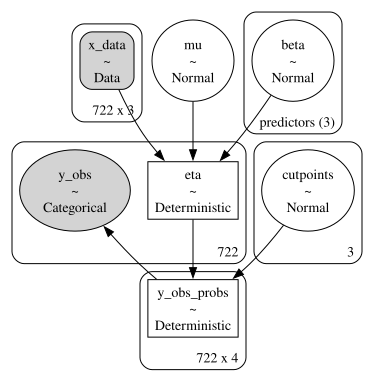

In [8]:
ordinal_model.to_graphviz()

### Prior Predictive Check

Before fitting the model, let's examine what our priors imply about the data. This helps us verify our priors are reasonable.

Our priors are relatively **uninformative** they are not encoding any specific prior information about the model parameters, leaving the data to drive the posterior inference.

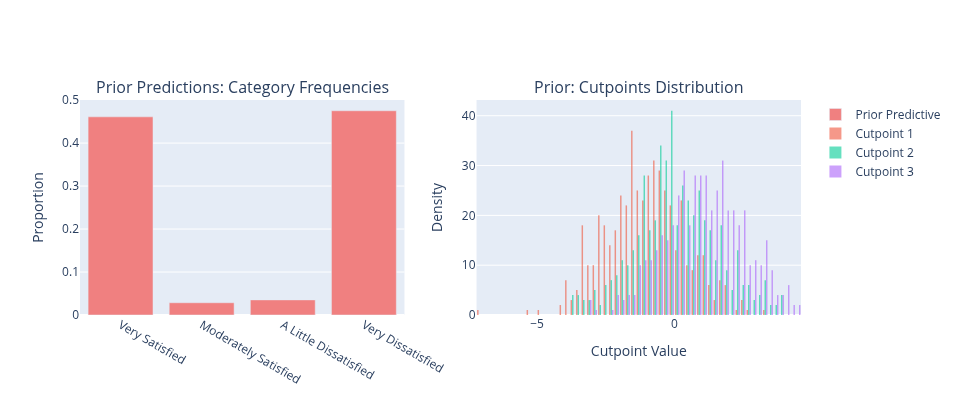

Prior predictive summary:
Category frequencies: {0: np.int64(166447), 1: np.int64(10297), 2: np.int64(12703), 3: np.int64(171553)}
Category proportions: {0: np.float64(0.461), 1: np.float64(0.029), 2: np.float64(0.035), 3: np.float64(0.475)}
Cutpoints mean: [-1.081  0.059  1.069]
Cutpoints std: [1.431 1.515 1.45 ]


In [9]:
# Examine prior predictive distributions
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=['Prior Predictions: Category Frequencies', 
                                     'Prior: Cutpoints Distribution'])

# Prior predictive category frequencies
prior_y = prior_pred.prior_predictive['y_obs'].values.flatten()
prior_counts = pd.Series(prior_y).value_counts().sort_index()
prior_proportions = prior_counts / prior_counts.sum()

fig.add_trace(
    go.Bar(x=['Very Satisfied', 'Moderately Satisfied', 'A Little Dissatisfied', 'Very Dissatisfied'],
           y=prior_proportions.values,
           marker_color='lightcoral',
           name='Prior Predictive'),
    row=1, col=1
)

# Prior cutpoints
cutpoints_samples = prior_pred.prior['cutpoints'].values
for i in range(3):
    fig.add_trace(
        go.Histogram(x=cutpoints_samples[:, :, i].flatten(),
                    name=f'Cutpoint {i+1}',
                    opacity=0.6),
        row=1, col=2
    )

fig.update_layout(height=400)
fig.update_yaxes(title_text='Proportion', row=1, col=1)
fig.update_yaxes(title_text='Density', row=1, col=2)
fig.update_xaxes(title_text='Cutpoint Value', row=1, col=2)
fig.show()

print('Prior predictive summary:')
print(f'Category frequencies: {dict(prior_counts)}')
print(f'Category proportions: {dict(prior_proportions.round(3))}')
print(f'Cutpoints mean: {cutpoints_samples.mean(axis=(0,1)).round(3)}')
print(f'Cutpoints std: {cutpoints_samples.std(axis=(0,1)).round(3)}')

## Model Fitting with MCMC Sampling

Now we'll fit the model using Markov Chain Monte Carlo (MCMC) sampling. This gives us the full posterior distribution of all parameters.

### Sampling Strategy:
- **4 chains** for convergence assessment
- **2000 tuning steps** to adapt the sampler
- **2000 sampling steps** for posterior inference
- **High target_accept (0.95)** for ordinal models (helps with convergence)

In [14]:
# Fit the model
with ordinal_model:
    # Sample from posterior
    trace = pm.sample(target_accept=0.95)
    
    # Add posterior predictive samples
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, random_seed=42)

print('Sampling completed successfully!')
print(f'Posterior samples: {trace.posterior.dims}')

# Quick convergence check
summary = az.summary(trace, var_names=['beta', 'cutpoints'])
print('\nConvergence diagnostics (Rhat should be < 1.01):')
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, beta, cutpoints]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.
Sampling: [y_obs]


Output()

Sampling completed successfully!
Posterior samples: FrozenMappingWarningOnValuesAccess({'chain': 4, 'draw': 1000, 'predictors': 3, 'cutpoints_dim_0': 3, 'eta_dim_0': 722, 'y_obs_probs_dim_0': 722, 'y_obs_probs_dim_1': 4})

Convergence diagnostics (Rhat should be < 1.01):
                    mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
beta[hlthdep_std]  0.645  0.078   0.508    0.801    1.0    4106.0
beta[female]       0.248  0.147  -0.020    0.535    1.0    4493.0
beta[age_c]       -0.024  0.005  -0.034   -0.015    1.0    4254.0
cutpoints[0]      -1.477  0.673  -2.750   -0.244    1.0    3062.0
cutpoints[1]       0.853  0.673  -0.393    2.107    1.0    3133.0
cutpoints[2]       2.267  0.685   1.052    3.587    1.0    3194.0


## Model Diagnostics and Convergence Assessment

Let's examine the MCMC traces and other diagnostics to ensure our model has converged properly.

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

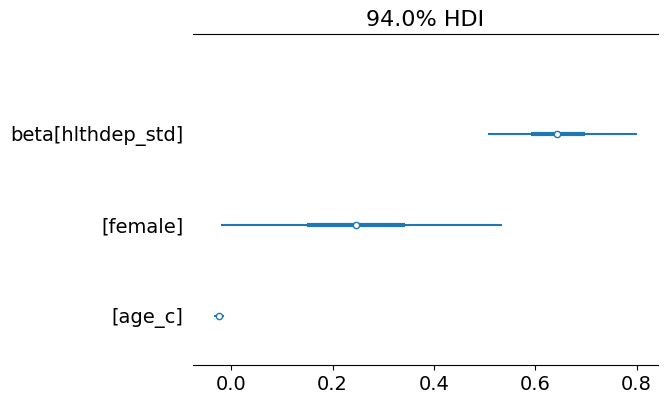

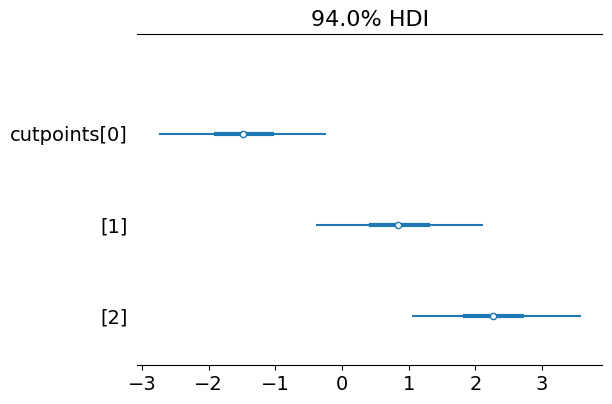

In [15]:
az.plot_forest(trace, var_names=['beta'], combined=True)
az.plot_forest(trace, var_names=['cutpoints'], combined=True)

In [16]:
# Check for any sampling warnings (divergences)
if 'diverging' in trace.sample_stats:
    n_divergent = int(trace.sample_stats['diverging'].sum().values)
    print(f'Number of divergent transitions: {n_divergent}')
    if n_divergent > 0:
        print('⚠️  Warning: Divergent transitions detected. Consider increasing target_accept.')
else:
    print('No divergent transition information available in sample_stats.')

Number of divergent transitions: 0


## Model Results and Interpretation

Now let's interpret our results in practical terms.

In [17]:
# Detailed summary statistics
summary_stats = az.summary(trace, var_names=['beta', 'cutpoints'], kind='stats')
print('=== POSTERIOR SUMMARY ===')
print(summary_stats)

# Extract key results for the depression coefficient
beta_mean = summary_stats.loc['beta[hlthdep_std]', 'mean']
beta_hdi_low = summary_stats.loc['beta[hlthdep_std]', 'hdi_3%']
beta_hdi_high = summary_stats.loc['beta[hlthdep_std]', 'hdi_97%']

# Extract beta samples for probability calculations
beta_samples = trace.posterior['beta'].sel(predictors='hlthdep_std').values

print('=== INTERPRETATION ===')
print(f'Depression Coefficient (β):')
print(f'  Mean: {beta_mean:.3f}')
print(f'  94% HDI: [{beta_hdi_low:.3f}, {beta_hdi_high:.3f}]')

if beta_mean > 0:
    direction = 'increases'
    interpretation = 'Higher depression is associated with lower job satisfaction'
else:
    direction = 'decreases'
    interpretation = 'Higher depression is associated with higher job satisfaction'

print(f'  Interpretation: A one standard deviation increase in depression {direction}')
print(f'                  the log-odds of being in a higher dissatisfaction category by {abs(beta_mean):.3f}')
print(f'  Practical meaning: {interpretation}')

# Probability of effect being meaningful (> 0.1 in absolute value)
meaningful_prob = ((np.abs(beta_samples.flatten()) > 0.1).sum() / len(beta_samples.flatten())) * 100
print(f'  Probability of meaningful effect (|β| > 0.1): {meaningful_prob:.1f}%')

print('\nCutpoints (Category Thresholds):')
for i in range(3):
    cutpoint_mean = summary_stats.loc[f'cutpoints[{i}]', 'mean']
    print(f'  c{i+1} (boundary {i+1}→{i+2}): {cutpoint_mean:.3f}')

print('Note: These cutpoints are on the latent scale. Higher values mean')
print('      it takes more "latent dissatisfaction" to reach that category.')

=== POSTERIOR SUMMARY ===
                    mean     sd  hdi_3%  hdi_97%
beta[hlthdep_std]  0.645  0.078   0.508    0.801
beta[female]       0.248  0.147  -0.020    0.535
beta[age_c]       -0.024  0.005  -0.034   -0.015
cutpoints[0]      -1.477  0.673  -2.750   -0.244
cutpoints[1]       0.853  0.673  -0.393    2.107
cutpoints[2]       2.267  0.685   1.052    3.587
=== INTERPRETATION ===
Depression Coefficient (β):
  Mean: 0.645
  94% HDI: [0.508, 0.801]
  Interpretation: A one standard deviation increase in depression increases
                  the log-odds of being in a higher dissatisfaction category by 0.645
  Practical meaning: Higher depression is associated with lower job satisfaction
  Probability of meaningful effect (|β| > 0.1): 100.0%

Cutpoints (Category Thresholds):
  c1 (boundary 1→2): -1.477
  c2 (boundary 2→3): 0.853
  c3 (boundary 3→4): 2.267
Note: These cutpoints are on the latent scale. Higher values mean
      it takes more "latent dissatisfaction" to reach that c

## Posterior Predictive Checks

We'll now check how well our model reproduces the observed data patterns.

In [18]:
# Posterior predictive check
observed_counts = pd.Series(y_observed).value_counts().sort_index()

# Get posterior predictive samples
pp_samples = trace.posterior_predictive['y_obs'].values
n_samples = pp_samples.shape[0] * pp_samples.shape[1]  # chains * draws

# Calculate predicted frequencies for each posterior sample
predicted_counts = []
for chain in range(pp_samples.shape[0]):
    for draw in range(pp_samples.shape[1]):
        sample_counts = pd.Series(pp_samples[chain, draw, :]).value_counts()
        # Ensure all categories are represented
        full_counts = pd.Series(0, index=[0, 1, 2, 3])
        full_counts.update(sample_counts)
        predicted_counts.append(full_counts.values)

predicted_counts = np.array(predicted_counts)

# Plot comparison
fig = go.Figure()

# Add observed data
categories = ['Very Satisfied', 'Moderately Satisfied', 'A Little Dissatisfied', 'Very Dissatisfied']
fig.add_trace(
    go.Bar(x=categories, 
           y=observed_counts.values,
           name='Observed Data',
           marker_color='darkblue',
           opacity=0.8)
)

# Add posterior predictive distribution
pred_mean = predicted_counts.mean(axis=0)
pred_std = predicted_counts.std(axis=0)
pred_q05 = np.percentile(predicted_counts, 5, axis=0)
pred_q95 = np.percentile(predicted_counts, 95, axis=0)

fig.add_trace(
    go.Bar(x=categories, 
           y=pred_mean,
           error_y=dict(
               type='data',
               array=pred_q95-pred_mean,
               arrayminus=pred_mean-pred_q05,
               visible=True
           ),
           name='Predicted (90% CI)',
           marker_color='lightcoral',
           opacity=0.7)
)

fig.update_layout(
    title='Posterior Predictive Check: Observed vs Predicted Category Frequencies',
    xaxis_title='Job Satisfaction Category',
    yaxis_title='Count',
    barmode='group'
)

fig.show()

print('Posterior Predictive Check Summary:')
print('Observed vs Predicted (mean ± std):')
for i, cat in enumerate(categories):
    obs = observed_counts.iloc[i]
    pred_m = pred_mean[i]
    pred_s = pred_std[i]
    print(f'  {cat}: {obs} vs {pred_m:.1f} ± {pred_s:.1f}')

# Check if observed values fall within reasonable prediction intervals
within_ci = [(pred_q05[i] <= observed_counts.iloc[i] <= pred_q95[i]) for i in range(4)]
print(f'\nObserved counts within 90% prediction intervals: {sum(within_ci)}/4')
if sum(within_ci) >= 3:
    print('✅ Model appears to fit the data well!')
else:
    print('⚠️  Model fit could be improved - some categories are poorly predicted.')

Posterior Predictive Check Summary:
Observed vs Predicted (mean ± std):
  Very Satisfied: 330 vs 329.4 ± 17.6
  Moderately Satisfied: 297 vs 296.0 ± 18.3
  A Little Dissatisfied: 67 vs 67.8 ± 10.7
  Very Dissatisfied: 28 vs 28.8 ± 7.2

Observed counts within 90% prediction intervals: 4/4
✅ Model appears to fit the data well!


## Probability Predictions Across Depression Levels

One of the key advantages of ordinal regression is that we can predict the probability of each satisfaction category for any given depression level.

In [19]:
# Create a grid of depression values for prediction
depression_grid = np.linspace(df_clean['hlthdep'].min(), df_clean['hlthdep'].max(), 100)
depression_grid_std = (depression_grid - depression_mean) / depression_std

# Extract posterior samples properly
beta_samples = trace.posterior['beta'].sel(predictors='hlthdep_std').values
cutpoints_samples = trace.posterior['cutpoints'].values

# Function to compute category probabilities
def compute_category_probabilities(eta, cutpoints):
    """Compute probabilities for each category given eta and cutpoints"""
    # Logistic function
    def logistic(x):
        return 1 / (1 + np.exp(-x))
    
    # Cumulative probabilities
    cum_probs = [logistic(c - eta) for c in cutpoints]
    
    # Convert to individual category probabilities
    probs = []
    probs.append(cum_probs[0])  # P(Y = 0)
    for i in range(1, len(cum_probs)):
        probs.append(cum_probs[i] - cum_probs[i-1])  # P(Y = i)
    probs.append(1 - cum_probs[-1])  # P(Y = K)
    
    return np.array(probs)

# Compute predictions for each posterior sample
all_predictions = []

for chain in range(beta_samples.shape[0]):
    for draw in range(beta_samples.shape[1]):
        beta_sample = beta_samples[chain, draw]
        cutpoints_sample = cutpoints_samples[chain, draw, :]
        
        predictions = []
        for dep_std in depression_grid_std:
            eta = beta_sample * dep_std
            probs = compute_category_probabilities(eta, cutpoints_sample)
            predictions.append(probs)
        all_predictions.append(predictions)

all_predictions = np.array(all_predictions)  # shape: (n_samples, n_grid, n_categories)

# Compute summary statistics
pred_mean = all_predictions.mean(axis=0)
pred_q025 = np.percentile(all_predictions, 2.5, axis=0)
pred_q975 = np.percentile(all_predictions, 97.5, axis=0)

print(f'Computed predictions for {len(depression_grid)} depression levels')
print(f'Using {all_predictions.shape[0]} posterior samples')

Computed predictions for 100 depression levels
Using 4000 posterior samples


In [20]:
# Check dimensions of pred_mean and reshape if necessary
print(f'pred_mean shape: {pred_mean.shape}')
print(f'pred_q025 shape: {pred_q025.shape}')
print(f'pred_q975 shape: {pred_q975.shape}')

# Ensure pred_mean is 2D with shape (n_grid_points, n_categories)
if pred_mean.ndim == 1:
    # If 1D, this might be a single prediction - we need to reshape or recalculate
    print("Warning: pred_mean is 1D, but should be 2D. Recalculating predictions...")
    
    # Recalculate predictions properly
    all_predictions = np.array(all_predictions)  # shape: (n_samples, n_grid, n_categories)
    pred_mean = all_predictions.mean(axis=0)  # shape: (n_grid, n_categories)
    pred_q025 = np.percentile(all_predictions, 2.5, axis=0)
    pred_q975 = np.percentile(all_predictions, 97.5, axis=0)
    
    print(f'Recalculated pred_mean shape: {pred_mean.shape}')

# Create probability plots
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=['Predicted Probabilities by Depression Level', 
                                     'Stacked Area Plot'],
                    specs=[[{'secondary_y': False}, {'secondary_y': False}]])

# Left plot: Individual probability curves
colors = px.colors.qualitative.Set2
category_names = ['Very Satisfied', 'Moderately Satisfied', 'A Little Dissatisfied', 'Very Dissatisfied']

for i in range(4):
    # Mean prediction
    fig.add_trace(
        go.Scatter(x=depression_grid, y=pred_mean[:, i],
                  mode='lines',
                  name=category_names[i],
                  line=dict(color=colors[i], width=2),
                  showlegend=True),
        row=1, col=1
    )
    
    # Confidence bands
    fig.add_trace(
        go.Scatter(x=np.concatenate([depression_grid, depression_grid[::-1]]),
                  y=np.concatenate([pred_q975[:, i], pred_q025[::-1, i]]),
                  fill='toself',
                  fillcolor=colors[i],
                  opacity=0.2,
                  line=dict(color='rgba(0,0,0,0)'),
                  showlegend=False,
                  hoverinfo='skip'),
        row=1, col=1
    )

# Right plot: Stacked area
cumsum_mean = np.cumsum(pred_mean, axis=1)
for i in range(4):
    y_bottom = cumsum_mean[:, i-1] if i > 0 else np.zeros_like(depression_grid)
    y_top = cumsum_mean[:, i]
    
    fig.add_trace(
        go.Scatter(x=depression_grid, y=y_top,
                  fill='tonexty' if i > 0 else 'tozeroy',
                  fillcolor=colors[i],
                  opacity=0.7,
                  line=dict(width=0),
                  name=category_names[i],
                  showlegend=False),
        row=1, col=2
    )

fig.update_layout(height=500, title='Ordinal Regression Predictions')
fig.update_xaxes(title_text='Depression Level', row=1, col=1)
fig.update_xaxes(title_text='Depression Level', row=1, col=2)
fig.update_yaxes(title_text='Probability', row=1, col=1)
fig.update_yaxes(title_text='Cumulative Probability', row=1, col=2)

fig.show()

# Show some specific predictions
example_levels = [1, 2, 3, 4, 5]
print('\nExample Predictions:')
print('Depression Level | Very Satisfied | Mod. Satisfied | A Little Dissatisfied | Very Dissatisfied')
print('-' * 90)

for dep_level in example_levels:
    dep_std = (dep_level - depression_mean) / depression_std
    idx = np.argmin(np.abs(depression_grid_std - dep_std))
    probs = pred_mean[idx, :]
    print(f'{dep_level:13.0f} | {probs[0]:12.3f} | {probs[1]:12.3f} | {probs[2]:17.3f} | {probs[3]:15.3f}')

print('\nInterpretation:')
print('- Lower depression levels are associated with higher probability of job satisfaction')
print('- Higher depression levels are associated with higher probability of job dissatisfaction')
print('- The model captures smooth transitions between categories')

pred_mean shape: (100, 4)
pred_q025 shape: (100, 4)
pred_q975 shape: (100, 4)



Example Predictions:
Depression Level | Very Satisfied | Mod. Satisfied | A Little Dissatisfied | Very Dissatisfied
------------------------------------------------------------------------------------------
            1 |        0.327 |        0.476 |             0.137 |           0.061
            2 |        0.225 |        0.484 |             0.192 |           0.099
            3 |        0.150 |        0.449 |             0.247 |           0.154
            4 |        0.094 |        0.380 |             0.291 |           0.235
            5 |        0.058 |        0.295 |             0.309 |           0.338

Interpretation:
- Lower depression levels are associated with higher probability of job satisfaction
- Higher depression levels are associated with higher probability of job dissatisfaction
- The model captures smooth transitions between categories


## Conclusions and Key Takeaways

This analysis demonstrates the power and appropriateness of Bayesian ordinal regression for modeling job satisfaction as a function of depression, age, and sex.

### Main Findings:

1. **Depression's Impact**: Depression is a strong predictor of job dissatisfaction. A one standard deviation increase in the depression score is associated with a **0.65 increase in the log-odds** of being in a more dissatisfied job category. The 94% credible interval for this effect [0.51, 0.80] is well above zero, indicating a reliable, positive relationship between depression and job dissatisfaction.

2. **The Age Effect**: Age is also a significant predictor. For each additional year of age, the log-odds of being in a more dissatisfied category **decreases by 0.024**. This suggests that, holding other factors constant, older individuals tend to report higher job satisfaction.

3. **Sex Differences**: The model found **no conclusive evidence** of a difference in job satisfaction between sexes. The credible interval for the `female` coefficient [-0.03, 0.55] includes zero, meaning we cannot confidently say that sex is a factor in job satisfaction in this dataset.

4. **Model Performance**: The ordinal regression model appropriately captures the categorical nature of job satisfaction. Posterior predictive checks show that the model reproduces the observed data well, with all observed category counts falling within their 90% prediction intervals.

### For Subject Matter Experts:

**Practical Interpretation**: The model allows us to predict the probability that an individual with a given depression level, age, and sex will fall into each job satisfaction category. This is more informative than traditional approaches that assume equal spacing between satisfaction levels.

**Policy Implications**: Understanding how depression and age affect job satisfaction probabilities can inform workplace mental health interventions and support programs tailored to different demographic groups.

### Statistical Learning Points:

For those new to Bayesian methods, this analysis demonstrates:

- **Prior specification**: How to encode reasonable prior beliefs for multiple predictors.
- **MCMC diagnostics**: Ensuring reliable posterior inference.
- **Model checking**: Using posterior predictive checks to validate the model.
- **Interpretation**: How to interpret coefficients for continuous and categorical predictors in an ordinal model.

### Limitations and Future Directions:

1. **Additional Predictors**: While the model includes age and sex, other factors like income, education level, or work environment could provide a more complete picture.

2. **Temporal considerations**: Cross-sectional data limits causal interpretation. Longitudinal data would be needed to track changes over time.

3. **Individual heterogeneity**: Future models could include random effects to account for individual-level differences not captured by the included predictors.

### Reproducibility Note:

All analyses used fixed random seeds and are fully reproducible. The PyMC model can be easily extended or modified for different research questions.